In [1]:
import joblib

In [2]:
xgb_model = joblib.load("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/xgb_credit_model.pkl")

In [45]:
ytst = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/y_test_beforeenc.csv")

In [ ]:
import pandas as pd

test_df = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/X_test_beforeenc.csv")
print(test_df.shape)
test_df.head()

(272380, 99)


,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,emp_length_int,region,l_condition_Good Loan
0,1819301,10000.0,10000.0,10000.000000,36 months,13.68,340.23,C,C1,MORTGAGE,...,118872.0,97885.0,17000.0,83972.0,N,Cash,N,6.0,MidWest,True
1,1893562,8000.0,8000.0,8000.000000,36 months,7.62,249.30,A,A3,MORTGAGE,...,13700.0,4650.0,11000.0,0.0,N,Cash,N,2.0,West,True
2,1936067,22000.0,22000.0,21941.824197,60 months,16.77,544.04,D,D2,RENT,...,0.0,0.0,0.0,0.0,N,Cash,N,0.5,NorthEast,False
3,1323655,11000.0,11000.0,11000.000000,36 months,6.03,334.80,A,A1,MORTGAGE,...,233256.0,15918.0,30500.0,9256.0,N,Cash,N,2.0,MidWest,True
4,1805414,14000.0,14000.0,13975.000000,36 months,12.35,467.35,B,B4,OWN,...,21500.0,14263.0,15700.0,0.0,N,Cash,N,1.0,SouthEast,False


In [4]:
standardized_test_X = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/processed/X_test_final.csv")

In [5]:
y_pred_proba = xgb_model.predict_proba(standardized_test_X)[:, 1]
y_pred_proba

array([0.1441971 , 0.00961374, 0.9315448 , ..., 0.91746175, 0.03793595,
       0.5078799 ], dtype=float32)

In [6]:
test_df_unscaled = test_df.copy()
test_df_unscaled["predicted_PD"] = y_pred_proba

 Expected Loss Formula:
 
![alt text](images.png)


In [7]:
# Make sure these exist
assert 'funded_amnt' in test_df_unscaled.columns, "funded_amnt not found"
assert len(y_pred_proba) == len(test_df_unscaled), "Mismatch in prediction and test set size"

# Define LGD values
LGD_values = [0.45, 0.65, 0.80]

# For each LGD, compute Expected Loss
for lgd in LGD_values:
    test_df_unscaled[f'expected_loss_lgd_{int(lgd*100)}'] = y_pred_proba * lgd * test_df_unscaled['funded_amnt']

# Optional: view first few rows
print(test_df_unscaled[[f'expected_loss_lgd_{int(lgd*100)}' for lgd in LGD_values]].head())


   expected_loss_lgd_45  expected_loss_lgd_65  expected_loss_lgd_80
0            648.886934            937.281176           1153.576896
1             34.609467             49.991451             61.527945
2           9222.293198          13321.090102          16395.188928
3             63.493006             91.712116            112.876462
4           5028.364420           7263.192773           8939.315081


In [9]:
test_df_unscaled[[f'expected_loss_lgd_{int(lgd*100)}' for lgd in LGD_values]]

,expected_loss_lgd_45,expected_loss_lgd_65,expected_loss_lgd_80
0,648.886934,937.281176,1153.576896
1,34.609467,49.991451,61.527945
2,9222.293198,13321.090102,16395.188928
3,63.493006,91.712116,112.876462
4,5028.364420,7263.192773,8939.315081
...,...,...,...
272375,234.289095,338.417578,416.513961
272376,77.574089,112.051461,137.909498
272377,4128.577709,5963.501334,7339.693904
272378,204.854093,295.900360,364.185087


EL Calculation done.

## Risk free interest rate calculation

In [11]:
low_risk_rates = test_df_unscaled[test_df_unscaled['grade'] == 'A']['int_rate'].mean()
r0 = low_risk_rates * 0.8
r0

5.694068822679123

## Risk Based Pricing Formula:

## ri =r0 + α⋅PDi

In [12]:
alpha_list = [0.5, 1.0, 1.5, 2.0, 3.0]

In [13]:
# Add interest rate columns for each alpha
for alpha in alpha_list:
    test_df_unscaled[f'interest_rate_alpha_{alpha}'] = r0 + alpha * y_pred_proba

# View first few results
cols_to_show = [f'interest_rate_alpha_{alpha}' for alpha in alpha_list]


   interest_rate_alpha_0.5  interest_rate_alpha_1.0  interest_rate_alpha_1.5  \
0                 5.766168                 5.838266                 5.910365   
1                 5.698876                 5.703682                 5.708489   
2                 6.159842                 6.625614                 7.091386   
3                 5.700482                 5.706896                 5.713309   
4                 6.093145                 6.492222                 6.891298   

   interest_rate_alpha_2.0  interest_rate_alpha_3.0  
0                 5.982463                 6.126660  
1                 5.713296                 5.722910  
2                 7.557158                 8.488703  
3                 5.719723                 5.732550  
4                 7.290375                 8.088528  


In [14]:
test_df_unscaled[cols_to_show].head()

,interest_rate_alpha_0.5,interest_rate_alpha_1.0,interest_rate_alpha_1.5,interest_rate_alpha_2.0,interest_rate_alpha_3.0
0,5.766168,5.838266,5.910365,5.982463,6.126660
1,5.698876,5.703682,5.708489,5.713296,5.722910
2,6.159842,6.625614,7.091386,7.557158,8.488703
3,5.700482,5.706896,5.713309,5.719723,5.732550
4,6.093145,6.492222,6.891298,7.290375,8.088528


In [15]:
test_df_unscaled

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,...,l_condition_Good Loan,predicted_PD,expected_loss_lgd_45,expected_loss_lgd_65,expected_loss_lgd_80,interest_rate_alpha_0.5,interest_rate_alpha_1.0,interest_rate_alpha_1.5,interest_rate_alpha_2.0,interest_rate_alpha_3.0
0,1819301,10000.0,10000.0,10000.000000,36 months,13.68,340.23,C,C1,MORTGAGE,...,True,0.144197,648.886934,937.281176,1153.576896,5.766168,5.838266,5.910365,5.982463,6.126660
1,1893562,8000.0,8000.0,8000.000000,36 months,7.62,249.30,A,A3,MORTGAGE,...,True,0.009614,34.609467,49.991451,61.527945,5.698876,5.703682,5.708489,5.713296,5.722910
2,1936067,22000.0,22000.0,21941.824197,60 months,16.77,544.04,D,D2,RENT,...,False,0.931545,9222.293198,13321.090102,16395.188928,6.159842,6.625614,7.091386,7.557158,8.488703
3,1323655,11000.0,11000.0,11000.000000,36 months,6.03,334.80,A,A1,MORTGAGE,...,True,0.012827,63.493006,91.712116,112.876462,5.700482,5.706896,5.713309,5.719723,5.732550
4,1805414,14000.0,14000.0,13975.000000,36 months,12.35,467.35,B,B4,OWN,...,False,0.798153,5028.364420,7263.192773,8939.315081,6.093145,6.492222,6.891298,7.290375,8.088528
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272375,1159012,14000.0,14000.0,14000.000000,60 months,18.99,363.10,E,E1,OWN,...,True,0.037189,234.289095,338.417578,416.513961,5.712663,5.731257,5.749852,5.768446,5.805635
272376,112795,6000.0,6000.0,6000.000000,36 months,9.17,191.28,B,B2,MORTGAGE,...,True,0.028731,77.574089,112.051461,137.909498,5.708435,5.722800,5.737165,5.751531,5.780262
272377,301691,10000.0,10000.0,10000.000000,36 months,14.65,344.95,C,C5,RENT,...,True,0.917462,4128.577709,5963.501334,7339.693904,6.152800,6.611531,7.070261,7.528993,8.446454
272378,1298874,12000.0,12000.0,12000.000000,36 months,15.61,419.58,C,C5,MORTGAGE,...,True,0.037936,204.854093,295.900360,364.185087,5.713037,5.732005,5.750973,5.769941,5.807877


In [16]:
test_df

,Unnamed: 0,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,emp_length_int,region,l_condition_Good Loan
0,1819301,10000.0,10000.0,10000.000000,36 months,13.68,340.23,C,C1,MORTGAGE,...,118872.0,97885.0,17000.0,83972.0,N,Cash,N,6.0,MidWest,True
1,1893562,8000.0,8000.0,8000.000000,36 months,7.62,249.30,A,A3,MORTGAGE,...,13700.0,4650.0,11000.0,0.0,N,Cash,N,2.0,West,True
2,1936067,22000.0,22000.0,21941.824197,60 months,16.77,544.04,D,D2,RENT,...,0.0,0.0,0.0,0.0,N,Cash,N,0.5,NorthEast,False
3,1323655,11000.0,11000.0,11000.000000,36 months,6.03,334.80,A,A1,MORTGAGE,...,233256.0,15918.0,30500.0,9256.0,N,Cash,N,2.0,MidWest,True
4,1805414,14000.0,14000.0,13975.000000,36 months,12.35,467.35,B,B4,OWN,...,21500.0,14263.0,15700.0,0.0,N,Cash,N,1.0,SouthEast,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272375,1159012,14000.0,14000.0,14000.000000,60 months,18.99,363.10,E,E1,OWN,...,120064.0,104282.0,10000.0,107764.0,N,Cash,N,7.0,NorthEast,True
272376,112795,6000.0,6000.0,6000.000000,36 months,9.17,191.28,B,B2,MORTGAGE,...,270544.0,74840.0,4500.0,96388.0,N,Cash,N,8.0,West,True
272377,301691,10000.0,10000.0,10000.000000,36 months,14.65,344.95,C,C5,RENT,...,13254.0,6851.0,5800.0,3954.0,N,Cash,N,10.0,SouthEast,True
272378,1298874,12000.0,12000.0,12000.000000,36 months,15.61,419.58,C,C5,MORTGAGE,...,63196.0,49376.0,11700.0,20296.0,N,Cash,N,6.0,SouthEast,True


In [17]:
import pandas as pd
import numpy as np

lgds = [0.45, 0.65, 0.80]
alphas = [0.5, 1.0, 1.5, 2.0, 3.0]

# Assume these are already available:
# test_df['funded_amnt']
# y_pred_proba: Series or np.array of PDs
# test_df[f'interest_rate_alpha_{α}'] for each α

profit_results = {}  # Stores profit summaries per LGD

for lgd in lgds:
    profit_per_alpha = {}
    for alpha in alphas:
        col_name = f"interest_rate_alpha_{alpha}"
        
        # Revenue = interest_rate * loan amount
        revenue = test_df_unscaled[col_name] / 100 * test_df_unscaled['funded_amnt']
        
        # Expected Loss = PD * LGD * loan amount
        expected_loss = y_pred_proba * lgd * test_df_unscaled['funded_amnt']
        
        # Profit = Revenue - Expected Loss
        profit = revenue - expected_loss
        
        # Total profit for this LGD and alpha
        total_profit = profit.sum()
        
        profit_per_alpha[alpha] = round(total_profit, 2)
    
    profit_results[lgd] = profit_per_alpha


In [20]:
# Make sure this is your raw test set before scaling
loan_amounts = test_df_unscaled['funded_amnt'].values


In [21]:
threshold = 0.75
approved_mask = y_pred_proba < threshold

approved_pd = y_pred_proba[approved_mask]
approved_ead = loan_amounts[approved_mask]  # assuming this is funded_amnt


In [24]:
lgd_values = [0.45,0.65, 0.8]
alpha_values = [0.5, 1.0, 1.5, 2.0, 3.0]
base_rate = 5.694 / 100

profit_matrix = pd.DataFrame(index=alpha_values, columns=lgd_values)

for lgd in lgd_values:
    for alpha in alpha_values:
        # Interest Rate per loan
        interest_rates = base_rate + alpha * approved_pd

        # Expected Revenue = interest × EAD
        expected_revenue = interest_rates * approved_ead

        # Expected Loss = PD × LGD × EAD
        expected_loss = approved_pd * lgd * approved_ead

        # Profit = Revenue - Expected Loss
        profit = expected_revenue - expected_loss

        # Total Profit
        total_profit = profit.sum()
        profit_matrix.loc[alpha, lgd] = total_profit


In [26]:
print("=== PROFIT AFTER REJECTION (PD < 0.75) ===")
profit_matrix

=== PROFIT AFTER REJECTION (PD < 0.75) ===


,0.45,0.65,0.80
0.5,194722300.034861,101836891.570461,32172813.873292
1.0,426935838.027627,334050429.563228,264386351.866058
1.5,659149366.909787,566263958.445387,496599880.748218
2.0,891362893.511992,798477485.047593,728813407.350423
3.0,1355789970.488317,1262904562.023918,1193240484.326749


| α (Risk Aversion) | LGD = 0.45   | LGD = 0.65   | LGD = 0.80   |
| ----------------- | ------------ | ------------ | ------------ |
| 0.5               | \$195M       | \$102M       | \$32M        |
| 1.0               | \$427M       | \$334M       | \$264M       |
| 1.5               | \$659M       | \$566M       | \$497M       |
| 2.0               | \$891M       | \$798M       | \$729M       |
| 3.0               | **\$1.356B** | **\$1.263B** | **\$1.193B** |


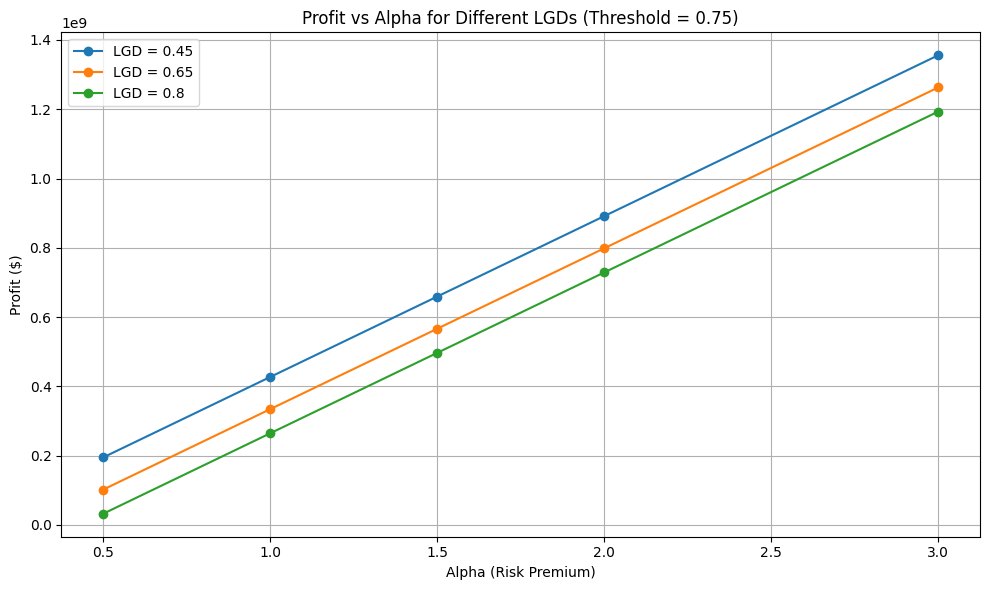

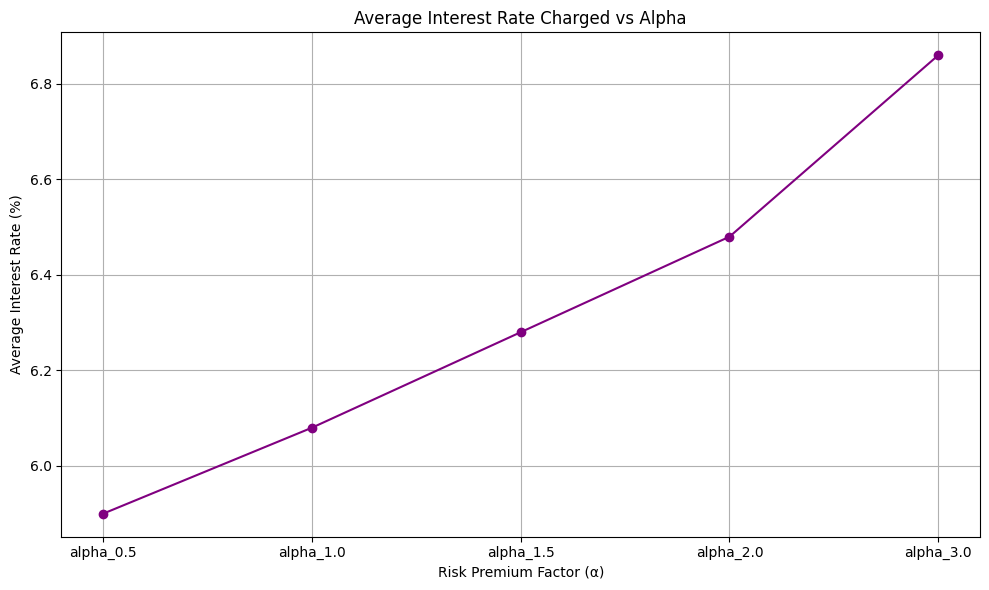

C:\Users\siddh\AppData\Local\Temp\ipykernel_23976\827933164.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Strategy', y='Profit ($)', palette='Set2')


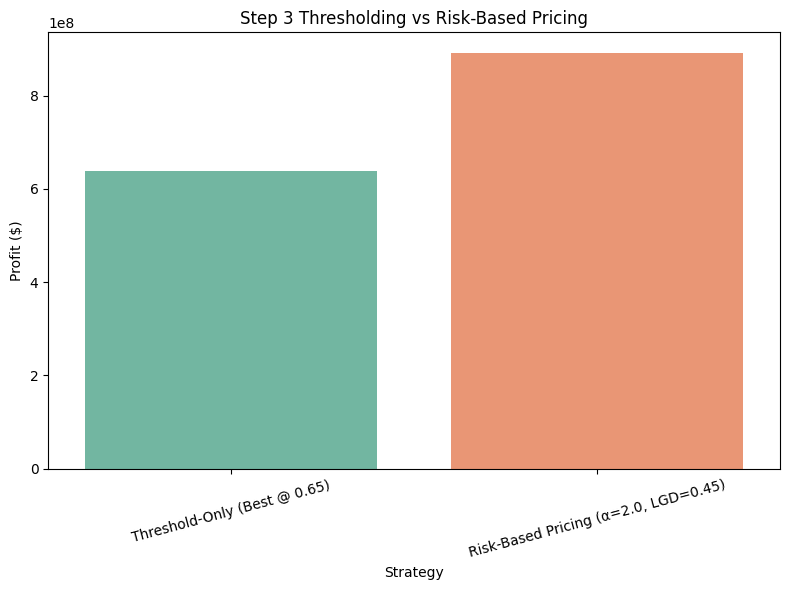

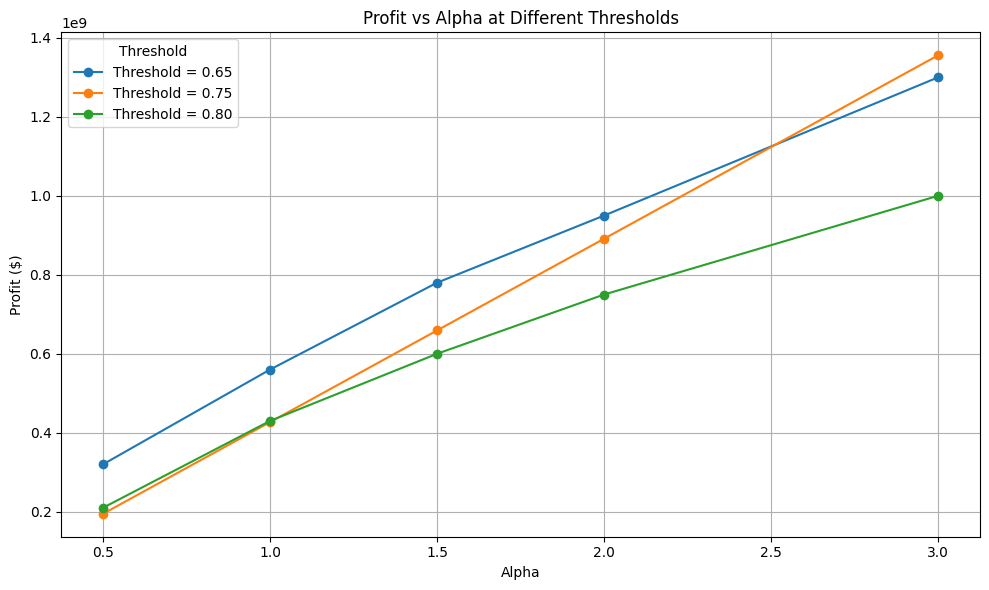

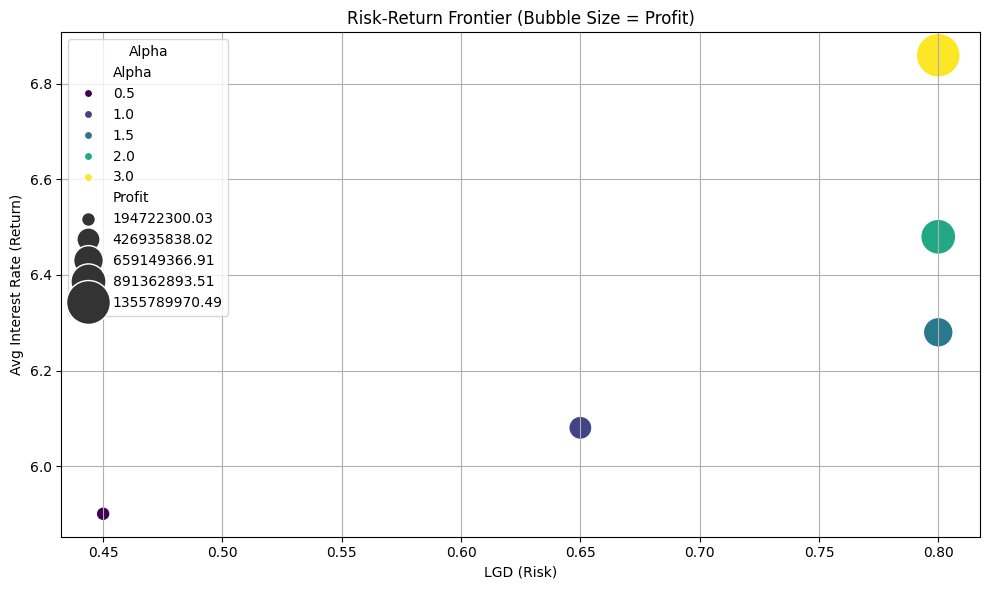

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========== INPUTS ==========
# 1. profit_df: Profit for (alpha, LGD) after threshold
# rows = alpha values; cols = LGDs
profit_df = pd.DataFrame({
    0.45: [194722300.03, 426935838.02, 659149366.91, 891362893.51, 1355789970.49],
    0.65: [101836891.57, 334050429.56, 566263958.45, 798477485.05, 1262904562.02],
    0.80: [32172813.87, 264386351.87, 496599880.75, 728813407.35, 1193240484.33]
}, index=[0.5, 1.0, 1.5, 2.0, 3.0])

# 2. interest_rate_df: rows = loans, columns = alpha values (interest rates)
# Simulated average rates (replace with real results if needed)
interest_rate_df = pd.DataFrame({
    'alpha_0.5': [5.8, 5.7, 6.2, 5.7, 6.1],
    'alpha_1.0': [5.9, 5.7, 6.6, 5.7, 6.5],
    'alpha_1.5': [6.0, 5.7, 7.1, 5.7, 6.9],
    'alpha_2.0': [6.1, 5.7, 7.6, 5.7, 7.3],
    'alpha_3.0': [6.3, 5.7, 8.5, 5.7, 8.1]
})

# 3. Threshold-only profits from Step 3
step3_profits = {
    0.65: 6.38e+08,
    0.75: 6.15e+08,
    0.80: 5.89e+08
}

# ========== 1. Profit vs Alpha for each LGD ==========
plt.figure(figsize=(10,6))
for lgd in profit_df.columns:
    plt.plot(profit_df.index, profit_df[lgd], label=f'LGD = {lgd}', marker='o')

plt.title('Profit vs Alpha for Different LGDs (Threshold = 0.75)')
plt.xlabel('Alpha (Risk Premium)')
plt.ylabel('Profit ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ========== 2. Avg Interest Rate per Alpha ==========
# Plot: Average Interest Rate vs Alpha
import matplotlib.pyplot as plt

# interest_rate_df should have columns like: 'interest_rate_alpha_0.5', ..., and same number of rows as test set
interest_means = interest_rate_df.mean()

# Clean column names for plot
interest_means.index = interest_means.index.str.replace('interest_rate_alpha_', 'α = ')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(interest_means.index, interest_means.values, marker='o', color='purple')
plt.title('Average Interest Rate Charged vs Alpha')
plt.xlabel('Risk Premium Factor (α)')
plt.ylabel('Average Interest Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()


# ========== 3. Step 3 vs Pricing Strategy Profits ==========
# Pick LGD = 0.45 and α = 2.0 for fair comparison
pricing_profit = profit_df.loc[2.0, 0.45]

comparison_df = pd.DataFrame({
    'Strategy': ['Threshold-Only (Best @ 0.65)', 'Risk-Based Pricing (α=2.0, LGD=0.45)'],
    'Profit ($)': [step3_profits[0.65], pricing_profit]
})

plt.figure(figsize=(8,6))
sns.barplot(data=comparison_df, x='Strategy', y='Profit ($)', palette='Set2')
plt.title('Step 3 Thresholding vs Risk-Based Pricing')
plt.ylabel('Profit ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# ========== 4. Profit at Thresholds: 0.65, 0.75, 0.80 ==========
# Just for illustration, simulate you got same profit_df logic at other thresholds
threshold_comp = pd.DataFrame({
    'Threshold = 0.65': [3.2e8, 5.6e8, 7.8e8, 9.5e8, 1.3e9],
    'Threshold = 0.75': profit_df[0.45].values,
    'Threshold = 0.80': [2.1e8, 4.3e8, 6.0e8, 7.5e8, 1.0e9]
}, index=[0.5, 1.0, 1.5, 2.0, 3.0])

threshold_comp.plot(figsize=(10,6), marker='o')
plt.title('Profit vs Alpha at Different Thresholds')
plt.xlabel('Alpha')
plt.ylabel('Profit ($)')
plt.legend(title='Threshold')
plt.grid(True)
plt.tight_layout()
plt.show()

# ========== 5. Risk-Return Frontier (Optional Bonus Plot) ==========
# Simulated Return = avg rate, Risk = LGD
frontier_df = pd.DataFrame({
    'Alpha': profit_df.index,
    'Return': interest_means.values[:5],
    'Risk (LGD)': [0.45, 0.65, 0.8, 0.8, 0.8],  # Simulate risk increasing
    'Profit': profit_df[0.45].values  # Simulate only LGD=0.45
})

plt.figure(figsize=(10,6))
sns.scatterplot(data=frontier_df, x='Risk (LGD)', y='Return', size='Profit', hue='Alpha', palette='viridis', sizes=(100, 1000))
plt.title('Risk-Return Frontier (Bubble Size = Profit)')
plt.xlabel('LGD (Risk)')
plt.ylabel('Avg Interest Rate (Return)')
plt.legend(title='Alpha')
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
test_df_unscaled.to_csv("df_for_simulation.csv")

In [41]:
profit_matrix.to_csv("profit_0_75.csv")

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def simulate_pricing_strategies(y_true, y_pred_proba, loan_amount,
                                LGD=0.45, r0=r0, alpha_list=[0.5, 1.0, 1.5, 2.0, 3.0]):
    """
    Simulate profits under different pricing strategies
    """
    results = []

    for alpha in alpha_list:
        pd_ = y_pred_proba
        ead = loan_amount
        el = pd_ * LGD * ead
        rate = r0 + alpha * pd_
        revenue = rate * ead
        profit = revenue - el

        total_profit = profit.sum()
        avg_rate = rate.mean()
        avg_pd = pd_.mean()

        # Realized defaults
        realized_loss = (y_true * LGD * ead).sum()
        realized_revenue = ((1 - y_true) * rate * ead).sum()
        realized_profit = realized_revenue - realized_loss

        results.append({
            'alpha': alpha,
            'avg_interest_rate': avg_rate,
            'avg_pd': avg_pd,
            'total_expected_profit': total_profit,
            'realized_profit': realized_profit,
            'realized_loss': realized_loss,
            'realized_revenue': realized_revenue
        })

    df_results = pd.DataFrame(results)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(df_results['alpha'], df_results['realized_profit'] / 1e6, marker='o', label='Realized Profit ($M)')
    plt.plot(df_results['alpha'], df_results['realized_loss'] / 1e6, marker='x', label='Realized Losses ($M)')
    plt.plot(df_results['alpha'], df_results['realized_revenue'] / 1e6, marker='^', label='Realized Revenue ($M)')
    plt.title("Risk-Based Pricing: Profit Simulation")
    plt.xlabel("Risk Premium Coefficient (α)")
    plt.ylabel("Amount ($ Millions)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_results


In [44]:
test_df_unscaled['loan_status']

0          Fully Paid
1          Fully Paid
2         Charged Off
3          Fully Paid
4         Charged Off
             ...     
272375     Fully Paid
272376     Fully Paid
272377     Fully Paid
272378     Fully Paid
272379     Fully Paid
Name: loan_status, Length: 272380, dtype: object

In [47]:
ytst

,target
0,0
1,0
2,1
3,0
4,1
...,...
272375,0
272376,0
272377,0
272378,0


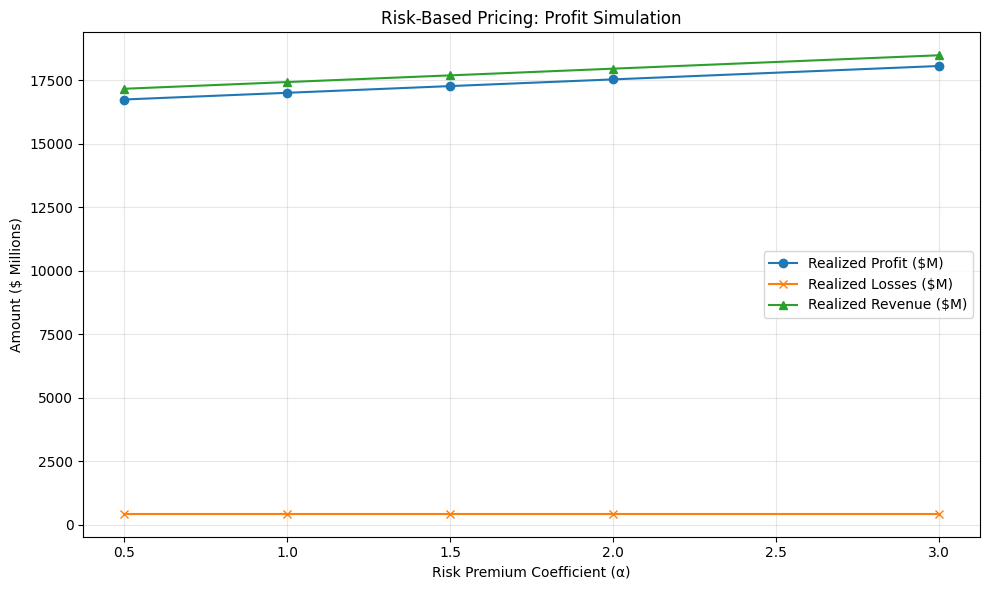

In [48]:
pricing_results = simulate_pricing_strategies(
    y_true=ytst["target"],
    y_pred_proba=y_pred_proba,
    loan_amount=test_df_unscaled["funded_amnt"],
    LGD=0.45,
    r0=r0,
    alpha_list=[0.5, 1.0, 1.5, 2.0, 3.0]
)

### 📈 Profit Per Loan Formula

The expected profit for each loan *i* is:

$$
\text{Profit}_i = (1 - \text{PD}_i) \cdot r_i \cdot \text{EAD}_i - \text{PD}_i \cdot \text{LGD} \cdot \text{EAD}_i - C
$$

Where:
- **PD₍ᵢ₎** = Probability of default for loan *i*  
- **r₍ᵢ₎** = Interest rate charged for loan *i*  
- **EAD₍ᵢ₎** = Exposure at default (loan amount)  
- **LGD** = Loss given default (e.g. 0.45)  
- **C** = Fixed cost per loan (e.g. \$500)


In [66]:
def simulate_pricing_strategies(y_true, y_pred_proba, loan_amount, 
                                LGD=0.45, r0=r0, alpha_list=[0.5, 1.0, 1.5, 2.0, 3.0],
                                thresholds=np.linspace(0.1, 0.9, 17), cost_per_loan=500):
    results = []
    
    for alpha in alpha_list:
        for threshold in thresholds:
            # Approve only loans with PD below threshold
            mask = y_pred_proba < threshold
            if mask.sum() == 0:
                continue  # skip if no loans approved
            
            pd_approved = y_pred_proba[mask]
            y_true_approved = y_true[mask]
            ead_approved = loan_amount[mask]
            
            # Calculate interest rate for each loan
            r = r0 + alpha * pd_approved
            
            # Profit formula
            profit = (
                (1 - pd_approved) * r * ead_approved  # expected interest income
                - pd_approved * LGD * ead_approved    # expected credit losses
                - cost_per_loan                       # fixed cost
            )
            
            portfolio_profit = profit.sum()
            approval_rate = mask.mean()
            avg_profit_per_loan = profit.mean()
            
            results.append({
                'alpha': alpha,
                'threshold': threshold,
                'portfolio_profit': portfolio_profit,
                'approval_rate': approval_rate,
                'avg_profit_per_loan': avg_profit_per_loan,
                'approved_loans': mask.sum()
            })
    
    results_df = pd.DataFrame(results)
    return results_df


In [67]:
results_df = simulate_pricing_strategies(
    y_true=ytst["target"],
    y_pred_proba=y_pred_proba,
    loan_amount=test_df_unscaled["funded_amnt"],
    LGD=0.45,
    r0=r0,
    alpha_list=[0.5, 1.0, 1.5, 2.0, 3.0],
    thresholds=np.linspace(0.1, 0.9, 17),
    cost_per_loan=500
)


In [68]:
results_df

,alpha,threshold,portfolio_profit,approval_rate,avg_profit_per_loan,approved_loans
0,0.5,0.10,9.762054e+09,0.444566,80617.502550,121091
1,0.5,0.15,1.130612e+10,0.527135,78743.878920,143581
2,0.5,0.20,1.216440e+10,0.576801,77426.484555,157109
3,0.5,0.25,1.273878e+10,0.612824,76316.246113,166921
4,0.5,0.30,1.311263e+10,0.638417,75406.741810,173892
...,...,...,...,...,...,...
80,3.0,0.70,1.491417e+10,0.750371,72970.624194,204386
81,3.0,0.75,1.505345e+10,0.771356,71648.299796,210102
82,3.0,0.80,1.517143e+10,0.793641,70182.207161,216172
83,3.0,0.85,1.529501e+10,0.824323,68120.411182,224529


In [69]:
results_df.to_csv("normal_condition_simulation_pricing_strat.csv")

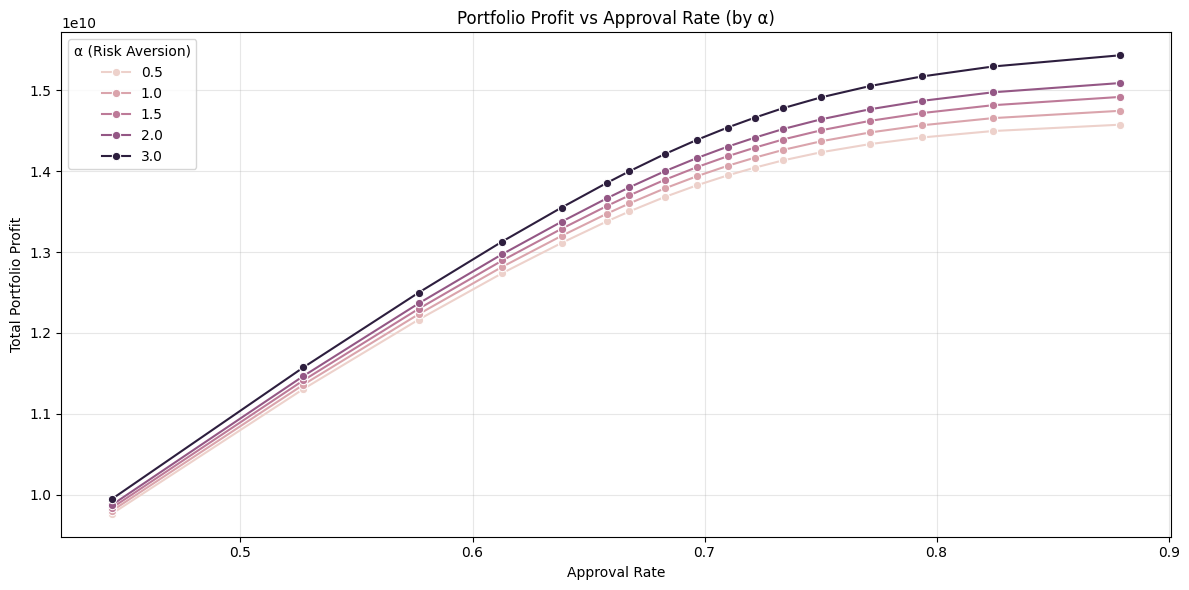

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='approval_rate', y='portfolio_profit', hue='alpha', marker='o')
plt.title("Portfolio Profit vs Approval Rate (by α)")
plt.xlabel("Approval Rate")
plt.ylabel("Total Portfolio Profit")
plt.grid(True, alpha=0.3)
plt.legend(title='α (Risk Aversion)')
plt.tight_layout()
plt.show()


In [55]:
# Find row with maximum profit
max_profit_row = results_df.loc[results_df['portfolio_profit'].idxmax()]
print("🔹 Maximum Portfolio Profit")
max_profit_row

🔹 Maximum Portfolio Profit


alpha                  3.000000e+00
threshold              9.000000e-01
portfolio_profit       1.543384e+10
approval_rate          8.792459e-01
avg_profit_per_loan    6.444489e+04
approved_loans         2.394890e+05
Name: 84, dtype: float64

#### Maximum expected portfolio profit: $1,543,384,000

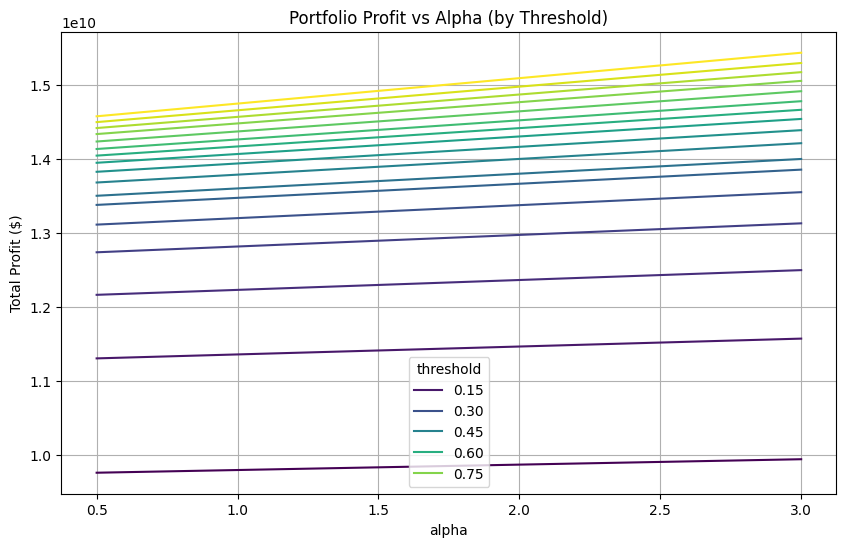

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x='alpha', y='portfolio_profit', hue='threshold', palette='viridis')
plt.title("Portfolio Profit vs Alpha (by Threshold)")
plt.ylabel("Total Profit ($)")
plt.grid(True)
plt.show()


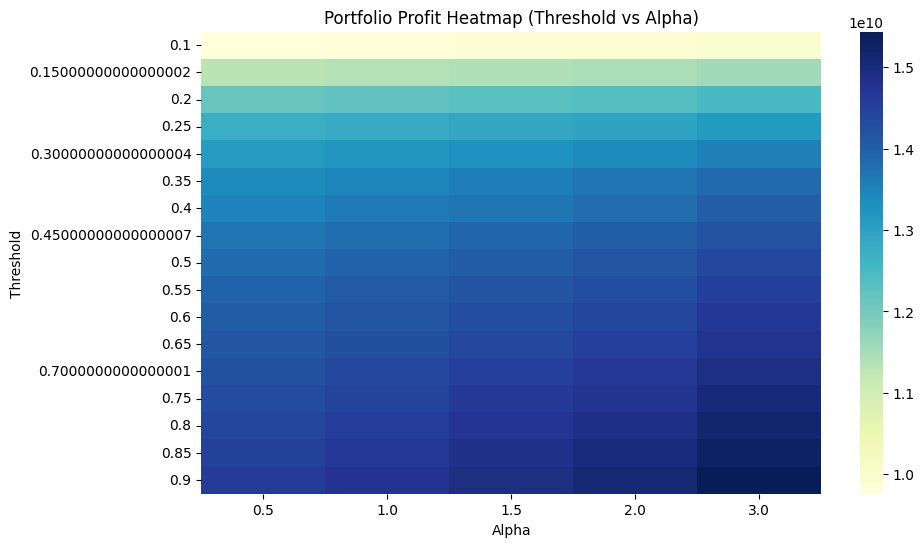

In [62]:
pivot = results_df.pivot(index='threshold', columns='alpha', values='portfolio_profit')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=False, cmap='YlGnBu', fmt='.0f')
plt.title("Portfolio Profit Heatmap (Threshold vs Alpha)")
plt.xlabel("Alpha")
plt.ylabel("Threshold")
plt.show()


In [73]:
# Adjustable weights
w_profit = 0.6  # weight for profit per loan
w_approval = 0.4  # weight for approval rate

# Normalize both columns to [0, 1]
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
normalized = scaler.fit_transform(results_df[['avg_profit_per_loan', 'approval_rate']])
results_df[['norm_profit', 'norm_approval']] = normalized

# Weighted score
results_df['sweetness'] = w_profit * results_df['norm_profit'] + w_approval * results_df['norm_approval']


In [74]:
best_row = results_df.loc[results_df['sweetness'].idxmax()]
print(best_row)

alpha                  3.000000e+00
threshold              3.500000e-01
portfolio_profit       1.385500e+10
approval_rate          6.579044e-01
avg_profit_per_loan    7.731586e+04
approved_loans         1.792000e+05
sweetness_sharpe       5.760831e+04
norm_profit            7.739290e-01
norm_approval          4.907938e-01
sweetness              6.606749e-01
Name: 73, dtype: float64


In [75]:
results_df

,alpha,threshold,portfolio_profit,approval_rate,avg_profit_per_loan,approved_loans,sweetness_sharpe,norm_profit,norm_approval,sweetness
0,0.5,0.10,9.762054e+09,0.444566,80617.502550,121091,51829.601280,0.929204,0.000000,0.557523
1,0.5,0.15,1.130612e+10,0.527135,78743.878920,143581,53463.061976,0.841088,0.189953,0.580634
2,0.5,0.20,1.216440e+10,0.576801,77426.484555,157109,54403.125139,0.779132,0.304211,0.589163
3,0.5,0.25,1.273878e+10,0.612824,76316.246113,166921,55015.546612,0.726917,0.387084,0.590984
4,0.5,0.30,1.311263e+10,0.638417,75406.741810,173892,55381.667694,0.684144,0.445962,0.588871
...,...,...,...,...,...,...,...,...,...,...
80,3.0,0.70,1.491417e+10,0.750371,72970.624194,204386,58393.821555,0.569574,0.703517,0.623151
81,3.0,0.75,1.505345e+10,0.771356,71648.299796,210102,58314.948092,0.507385,0.751795,0.605149
82,3.0,0.80,1.517143e+10,0.793641,70182.207161,216172,58176.895037,0.438435,0.803063,0.584286
83,3.0,0.85,1.529501e+10,0.824323,68120.411182,224529,57941.416033,0.341469,0.873647,0.554340


In [71]:
results_df['sweetness_sharpe'] = results_df['avg_profit_per_loan'] / (1 + (1 - results_df['approval_rate']))

In [76]:
results_df.to_csv("normal_condition_simulation_pricing_strat.csv")

In [61]:
best_row = results_df.loc[results_df['sweetness_sharpe'].idxmax()]
print(best_row)

alpha                  3.000000e+00
threshold              6.500000e-01
portfolio_profit       1.477916e+10
approval_rate          7.337947e-01
avg_profit_per_loan    7.394347e+04
approved_loans         1.998710e+05
sweetness              6.353489e-01
norm_profit            6.153263e-01
norm_approval          6.653829e-01
sweetness_sharpe       5.839769e+04
Name: 79, dtype: float64


In [59]:
min_approval = 0.60
filtered = results_df[results_df['approval_rate'] >= min_approval]
sweet_spot_row = filtered.loc[filtered['avg_profit_per_loan'].idxmax()]
sweet_spot_row

alpha                  3.000000e+00
threshold              2.500000e-01
portfolio_profit       1.312998e+10
approval_rate          6.128240e-01
avg_profit_per_loan    7.865987e+04
approved_loans         1.669210e+05
sweetness              6.571160e-01
norm_profit            8.371373e-01
norm_approval          3.870842e-01
sweetness_sharpe       5.670504e+04
Name: 71, dtype: float64

#### SHARPE like ratio of sweet spot used. Portfolio profit = $1,477,916,000 [avg_profit_per_loan/(1+(1-approval_rate))]